# Reanalysis of Epp et al. (2025, *Nature Neuroscience*)

We successfully retrieved data for **38 out of 40 subjects**.  
For the remaining **two subjects**, the data were missing from the OpenNeuro repository at the time of download.

Dataset source:  
https://openneuro.org/datasets/ds004873

---

## Overview of the Analysis Pipeline

The code below performs the following steps:

#### 1. **Import libraries and define paths**  
   Load required Python libraries and set up project directories.

#### 2. **Download dataset from OpenNeuro**  
   Retrieve the original dataset (`ds004873`) from OpenNeuro.

#### 3. **Compute BOLD percentage signal change (PSC)**  
   Calculate PSC maps from the BOLD signal.

#### 4. **Warp missing CMRO₂ maps to MNI space**  
   For subjects lacking CMRO₂ maps in MNI space, transform maps from **native → MNI space**.

#### 5. **Calculate sign probability across subjects (between CMRO2 and BOLD)**  

#### 6. **Test for BOLD sign voxels & test sign concordance** 

#### 7. **Generate Figure 1**  
   CV for baseline maps, task maps, and PSC.

#### 8. **Generate Figure 2**  
   BOLD activation mask and subject-wise sign coherence.

#### 9. **Group-level ΔCMRO₂ Classification**
   Within BOLD activation mask, test if there is a significant effect in CMRO2 and classify voxels in (a) concordant (b) discordant (c) CMRO2 not sign

#### 10. **Get CBF data and save concordancy.csv**
   

#### 11. **Generate Figure 3 (main result)**  
   Proportion of **concordant**, **discordant**, and **non-significant** CMRO₂ voxels.

---

## 1. **Import libraries, define paths and get sub-ID list**  

In [29]:
# --------------------------------------------------
# library
# --------------------------------------------------
import os
import glob
import gzip
import shutil
import subprocess
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib

from scipy.stats import binom, ttest_1samp
from statsmodels.stats.multitest import fdrcorrection

from nilearn import datasets, surface, plotting
from nilearn.image import load_img, new_img_like, resample_to_img
from nilearn.input_data import NiftiMasker

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms

from matplotlib.colors import (
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.cm import ScalarMappable
from matplotlib.offsetbox import TextArea, HPacker, AnchoredOffsetbox
from matplotlib import font_manager as fm

# --------------------------------------------------
# Paths 
# --------------------------------------------------

repo_root = Path.cwd()

base_path = repo_root
results_dir = base_path / "results"
fig_dir = base_path / "figures"

results_dir.mkdir(exist_ok=True)
fig_dir.mkdir(exist_ok=True)

# --------------------------------------------------
# Subjects
# --------------------------------------------------

txt_file = base_path / "subjects_with_all_data.txt"

with open(txt_file) as f:
    sids = [
        int(line.strip().replace("sub-p", ""))
        for line in f
        if line.strip()
    ]

n_subs = len(sids)

print(f"We will use {n_subs} subjects, with IDs:")
print(", ".join(map(str, sids)))

# --------------------------------------------------
# Analysis settings
# --------------------------------------------------

# Contrast of interest (main contrast reported in the paper)
task = "calc"
baseline = "control"

# Colors
nonsign_color = "#FEDDAB"
disc_color = "#37033599"
conc_color = "#07514999"

print(base_path)

We will use 38 subjects, with IDs:
19, 21, 23, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 43, 44, 46, 47, 48, 49, 50, 51, 52, 54, 55, 58, 59, 60, 61, 63, 64, 65, 66, 68
/home/ole/projects/BOLD_metabolism_reanalysis


## 2. **Download dataset from Openneuro**


If you want to re-run all analyses below, set `download = True` in the code cell below.  
This will download the original dataset from OpenNeuro using **DataLad**.

If `download = False`, the notebook performs the analysis based on the **summary statistics shared in this GitHub repository**.

In [2]:
download = False # <-- set to True if you want to download the full dataset

dataset_url = "https://github.com/OpenNeuroDatasets/ds004873.git"
dataset_dir = Path("ds004873")

if download:

    print("Download flag is True → fetching dataset from OpenNeuro")

    # clone dataset if necessary
    if not dataset_dir.exists():
        subprocess.run(
            ["datalad", "clone", dataset_url, str(dataset_dir)],
            check=True
        )
    else:
        print("Dataset already cloned.")

    # download derivatives
    subprocess.run(
        ["datalad", "get", "-r", "derivatives"],
        cwd=dataset_dir,
        check=True
    )

    print("Download complete.")

else:
    print("Download flag is False → using summary statistics provided in the repository.")

derivatives_dir = base_path / "ds004873/derivatives"

Download flag is False → using summary statistics provided in the repository.


## 3. **Compute BOLD percentage signal change (PSC)**
Code logic here is taken from https://github.com/NeuroenergeticsLab/two_modes_of_hemodynamics/blob/main/A_preprocessing.ipynb 

In [15]:
if not download:
    print("Download flag is False → using summary statistics provided in the repository.")

else:

    def idx(ranges):
        out = []
        for a, b in ranges:
            out.extend(range(a, b))
        return out


    def perc_change(func_arr, baseline_3d, eps=1e-6):
        """
        100*(X - baseline)/baseline with broadcasting.
        Sets voxels with invalid baseline (non-finite or <= eps) to NaN across all timepoints.
        """
        baseline = baseline_3d[..., None].astype(np.float32)
        func_arr = func_arr.astype(np.float32, copy=False)

        with np.errstate(divide="ignore", invalid="ignore"):
            pc = 100.0 * (func_arr - baseline) / baseline

        invalid = (~np.isfinite(baseline_3d)) | (baseline_3d <= eps)
        pc[invalid, :] = np.nan

        return pc.astype(np.float32, copy=False)


    # time windows (copied from github code)
    REST_BASE_LT56      = idx([(5,25), (130,150), (230,250), (330,350)])
    CONTROL_BASE_LT56   = idx([(80,100), (205,225), (280,300), (355,375)])
    CALC_WIN_LT56       = idx([(55,75), (155,175), (255,275), (305,325)])
    MEM_WIN_LT56        = idx([(30,50), (105,125), (180,200), (380,400)])

    CONTROL_BASE_GT55   = idx([(5,25), (55,75), (105,125), (155,175)])
    CALC_WIN_GT55       = idx([(30,50), (80,100), (130,150), (180,200)])

    out_suffix = "space-MNI152_res-2_desc-percchange_bold.nii.gz"


    def expected_outputs(derivatives_dir, sub, ID):
        """Return dict contrast->path for expected outputs for this subject."""
        if ID < 56:
            contrasts = ["calccontrol", "memcontrol", "calcrest"]
        else:
            contrasts = ["calccontrol"]

        paths = {
            con: os.path.join(derivatives_dir, sub, "func", f"{sub}_task-{con}_{out_suffix}")
            for con in contrasts
        }
        return paths


    def load_bold_4d(func_path, sub):
        """Load image + full data safely; return (img, data) or (None, None) with printed reason."""
        try:
            img = nib.load(func_path)
        except Exception as e:
            print(f"[SKIP] {sub}: cannot open NIfTI header: {type(e).__name__}: {e}")
            return None, None

        try:
            data = np.asanyarray(img.dataobj)
        except (EOFError, OSError, gzip.BadGzipFile) as e:
            print(f"[SKIP] {sub}: cannot read/decompress data (corrupt/truncated .nii.gz?): {type(e).__name__}: {e}")
            return None, None
        except Exception as e:
            print(f"[SKIP] {sub}: unexpected error while reading data: {type(e).__name__}: {e}")
            return None, None

        if data.ndim != 4:
            print(f"[SKIP] {sub}: expected 4D BOLD, got shape {data.shape}")
            return None, None

        return img, data


    for ID in sids:

        sub = f"sub-p{ID:03d}"

        func_path = os.path.join(
            derivatives_dir,
            sub,
            "func",
            f"{sub}task-all_space-MNI152_res-2_desc-preproc_bold.nii.gz"
        )

        # skip if outputs already exist
        out_paths = expected_outputs(derivatives_dir, sub, ID)

        if all(os.path.exists(p) for p in out_paths.values()):
            print(f"[SKIP] {sub}: outputs already exist ({len(out_paths)} files).")
            continue

        if not os.path.exists(func_path):
            print(f"[SKIP] {sub}: missing func file: {func_path}")
            continue

        print(f"[LOAD] {sub}")

        img, data = load_bold_4d(func_path, sub)
        if img is None:
            continue

        # Branch by subject ID
        if ID < 56:

            contrasts = ["calccontrol", "memcontrol", "calcrest"]

            baseline_rest = np.nanmedian(data[..., REST_BASE_LT56], axis=3)
            baseline_ctrl = np.nanmedian(data[..., CONTROL_BASE_LT56], axis=3)

            pc_rest = perc_change(data, baseline_rest)
            pc_ctrl = perc_change(data, baseline_ctrl)

            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="All-NaN slice encountered")

                maps = {
                    "calccontrol": np.nanmedian(pc_ctrl[..., CALC_WIN_LT56], axis=3),
                    "memcontrol":  np.nanmedian(pc_ctrl[..., MEM_WIN_LT56], axis=3),
                    "calcrest":    np.nanmedian(pc_rest[..., CALC_WIN_LT56], axis=3),
                }

        else:

            contrasts = ["calccontrol"]

            baseline_ctrl = np.nanmedian(data[..., CONTROL_BASE_GT55], axis=3)
            pc_ctrl = perc_change(data, baseline_ctrl)

            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="All-NaN slice encountered")

                maps = {
                    "calccontrol": np.nanmedian(pc_ctrl[..., CALC_WIN_GT55], axis=3)
                }

        # Save only missing outputs
        for con in contrasts:

            out_path = out_paths[con]

            if os.path.exists(out_path):
                print(f"  [SKIP] exists: {out_path}")
                continue

            out_img = nib.Nifti1Image(
                maps[con].astype(np.float32),
                img.affine,
                img.header
            )

            try:
                nib.save(out_img, out_path)
                print(f"  [SAVE] {out_path}")

            except Exception as e:
                print(f"  [FAIL] could not save {out_path}: {type(e).__name__}: {e}")

Download flag is False → using summary statistics provided in the repository.


## 4. **Warp missing CMRO₂ maps to MNI space**  

In [16]:
if not download:
    print("download = False → skipping CMRO2 warping (using precomputed results from repo).")

else:

    # ---------- helpers ----------
    def is_tool_available(name):
        return shutil.which(name) is not None


    def run_cmd(cmd):
        """Run command, print it, raise on failure with stderr."""
        print("    $", " ".join(cmd))
        p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if p.returncode != 0:
            raise RuntimeError(p.stderr.strip() or f"Command failed with code {p.returncode}")


    def first_existing(paths):
        for p in paths:
            if p and os.path.exists(p):
                return p
        return None


    def pick_t1w_ref(anat_dir, sub):
        """
        Pick a native T1w reference image (T1w space) for FLIRT -ref.
        Prefer fMRIPrep desc-preproc_T1w if present, otherwise any T1w-ish anat nifti.
        """
        candidates = []
        candidates += sorted(glob.glob(os.path.join(anat_dir, f"{sub}*_desc-preproc_T1w*.nii*")))
        candidates += sorted(glob.glob(os.path.join(anat_dir, f"{sub}*_T1w*.nii*")))
        # Avoid already-MNI files if any slipped in
        candidates = [c for c in candidates if "space-MNI" not in os.path.basename(c)]
        return first_existing(candidates)


    def warp_t2_to_mni(
        in_t2, out_mni, t1w_ref, mni_template, t2_to_t1_mat, t1_to_mni_h5,
        interp_flirt="trilinear", interp_ants="Linear"
    ):
        """
        Two-step:
          1) FLIRT applyxfm: T2 -> T1w (affine .mat)
          2) antsApplyTransforms: T1w -> MNI (nonlinear .h5), referenced to MNI template
        """
        os.makedirs(os.path.dirname(out_mni), exist_ok=True)

        with tempfile.TemporaryDirectory() as td:
            tmp_t1 = os.path.join(td, "tmp_space-T1w.nii.gz")

            # Step 1: T2 -> T1w
            flirt_cmd = [
                "flirt",
                "-in", in_t2,
                "-ref", t1w_ref,
                "-applyxfm",
                "-init", t2_to_t1_mat,
                "-interp", interp_flirt,
                "-out", tmp_t1,
            ]
            run_cmd(flirt_cmd)

            # Step 2: T1w -> MNI (reference = template)
            ants_cmd = [
                "antsApplyTransforms",
                "-d", "3",
                "-i", tmp_t1,
                "-r", mni_template,
                "-o", out_mni,
                "-t", t1_to_mni_h5,
                "-n", interp_ants,
            ]
            run_cmd(ants_cmd)


    # ---------- main ----------
    # MNI template
    mni_template = os.path.join(derivatives_dir, "MNI152_T1_2mm.nii.gz")
    if not os.path.exists(mni_template):
        raise FileNotFoundError(f"MNI template not found: {mni_template}")

    # required external tools
    for tool in ("flirt", "antsApplyTransforms"):
        if not is_tool_available(tool):
            raise RuntimeError(f"Required tool not found in PATH: {tool}")

    for ID in sids:
        sub = f"sub-p{ID:03d}"
        subj_dir = os.path.join(derivatives_dir, sub)
        anat_dir = os.path.join(subj_dir, "anat")
        qmri_dir = os.path.join(subj_dir, "qmri")

        print(f"\n=== {sub} ===")

        if not os.path.isdir(anat_dir):
            print(f"[SKIP] missing anat dir: {anat_dir}")
            continue
        if not os.path.isdir(qmri_dir):
            print(f"[SKIP] missing qmri dir: {qmri_dir}")
            continue

        # transforms
        t2_to_t1_mat = os.path.join(anat_dir, f"{sub}_desc-fmriprep_T2_to_T1w.mat")
        t1_to_mni_h5 = os.path.join(anat_dir, f"{sub}_from-T1w_to-MNI152NLin6Asym_mode-image_xfm.h5")

        if not os.path.exists(t2_to_t1_mat):
            print(f"[SKIP] missing T2->T1w affine: {t2_to_t1_mat}")
            continue
        if not os.path.exists(t1_to_mni_h5):
            print(f"[SKIP] missing T1w->MNI transform: {t1_to_mni_h5}")
            continue

        # reference for FLIRT
        t1w_ref = pick_t1w_ref(anat_dir, sub)
        if t1w_ref is None:
            print(f"[SKIP] could not find native T1w reference in {anat_dir}")
            continue

        print("  T1w ref:", t1w_ref)
        print("  MNI template:", mni_template)

        # outputs you want
        out_semi_mni = os.path.join(
            qmri_dir,
            f"{sub}_task-calc_base-control_space-MNI_desc-semi-quant-corrected_cmro2.nii.gz"
        )
        out_calc_mni = os.path.join(
            qmri_dir,
            f"{sub}_task-calc_space-MNI152_desc-orig_cmro2.nii.gz"
        )
        out_ctrl_mni = os.path.join(
            qmri_dir,
            f"{sub}_task-control_space-MNI152_desc-orig_cmro2.nii.gz"
        )

        # inputs you have (T2 space)
        in_semi_t2 = os.path.join(
            qmri_dir,
            f"{sub}_task-calc_base-control_space-T2_desc-semi-quant-corrected_cmro2.nii.gz"
        )
        in_calc_t2 = os.path.join(
            qmri_dir,
            f"{sub}_task-calc_space-T2_desc-orig_cmro2.nii"
        )
        in_ctrl_t2 = os.path.join(
            qmri_dir,
            f"{sub}_task-control_space-T2_desc-orig_cmro2.nii"
        )

        # jobs: only run if output missing
        jobs = [
            ("semi-quant-corrected", in_semi_t2, out_semi_mni),
            ("calc-orig", in_calc_t2, out_calc_mni),
            ("control-orig", in_ctrl_t2, out_ctrl_mni),
        ]

        if all(os.path.exists(o) for _, _, o in jobs):
            print("[SKIP] all MNI cmro2 outputs already exist.")
            continue

        for label, in_path, out_path in jobs:
            if os.path.exists(out_path):
                print(f"  [OK] exists: {os.path.basename(out_path)}")
                continue

            if not os.path.exists(in_path):
                print(f"  [SKIP] missing input for {label}: {os.path.basename(in_path)}")
                continue

            print(f"  [DO] {label}")
            try:
                warp_t2_to_mni(
                    in_t2=in_path,
                    out_mni=out_path,
                    t1w_ref=t1w_ref,
                    mni_template=mni_template,
                    t2_to_t1_mat=t2_to_t1_mat,
                    t1_to_mni_h5=t1_to_mni_h5,
                    interp_flirt="trilinear",
                    interp_ants="Linear",
                )
                print(f"  [SAVE] {out_path}")

            except Exception as e:
                print(f"  [FAIL] {sub} {label}: {type(e).__name__}: {e}")
                continue

download = False → skipping CMRO2 warping (using precomputed results from repo).


## 5. **Calculate sign probability across subjects (between CMRO2 and BOLD)**

In [17]:
if not download:
    print("download = False → skipping voxelwise sign-proportion computation (using CSV shipped with repo).")

else:

    # -------------------------
    # Config
    # -------------------------
    con = f"{task}{baseline}"

    whole_brain_mask = os.path.join(
        derivatives_dir,
        "task-all_space-MNI152_res-2_SNR_YEO_group_mask.nii.gz"
    )

    out_csv = os.path.join(
        results_dir,
        "voxelwise_signprops.csv"
    )

    # -------------------------
    # Path helpers
    # -------------------------
    def bold_percchange_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "func",
            f"{sub}_task-{con}_space-MNI152_res-2_desc-percchange_bold.nii.gz"
        )


    def cmro2_baseline_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{baseline}_space-MNI152_desc-orig_cmro2.nii.gz"
        )


    def cmro2_task_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{task}_base-{baseline}_space-MNI_desc-semi-quant-corrected_cmro2.nii.gz"
        )

    # -------------------------
    # Load mask + helpers
    # -------------------------
    if not os.path.exists(whole_brain_mask):
        raise FileNotFoundError(f"Mask not found: {whole_brain_mask}")

    mask_img = load_img(whole_brain_mask)


    def sanitize_then_resample(path: str, ref_img, interpolation="continuous", fill=0.0):
        img = load_img(path)
        data = img.get_fdata(dtype=np.float32)
        data[~np.isfinite(data)] = fill
        return resample_to_img(new_img_like(img, data), ref_img, interpolation=interpolation)


    masker = NiftiMasker(mask_img=mask_img).fit()

    # -------------------------
    # Load subject vectors
    # -------------------------
    bold_list, dcmro2_list, kept_sids, skipped = [], [], [], []

    for ID in sids:
        sub = f"sub-p{ID:03d}"
        f_bold = bold_percchange_path(sub)
        f_cmr0 = cmro2_baseline_path(sub)
        f_cmrt = cmro2_task_path(sub)

        missing = [f for f in (f_bold, f_cmr0, f_cmrt) if not os.path.exists(f)]
        if missing:
            skipped.append((sub, missing))
            continue

        try:
            bold_img = sanitize_then_resample(f_bold, mask_img)
            cmr0_img = sanitize_then_resample(f_cmr0, mask_img)
            cmrt_img = sanitize_then_resample(f_cmrt, mask_img)

            bold_v = masker.transform(bold_img).ravel().astype(np.float64)
            cmr0_v = masker.transform(cmr0_img).ravel().astype(np.float64)
            cmrt_v = masker.transform(cmrt_img).ravel().astype(np.float64)

            cmr0_v[~np.isfinite(cmr0_v)] = np.nan
            cmr0_v[cmr0_v <= 0] = np.nan
            dcmr_v = (cmrt_v - cmr0_v) / cmr0_v * 100.0
            dcmr_v[~np.isfinite(dcmr_v)] = np.nan

            bold_list.append(bold_v)
            dcmro2_list.append(dcmr_v)
            kept_sids.append(ID)

        except Exception as e:
            skipped.append((sub, [f"{type(e).__name__}: {e}"]))

    bold_arr = np.asarray(bold_list)    # (Nsub, Nvox)
    dcmr_arr = np.asarray(dcmro2_list)  # (Nsub, Nvox)

    print(f"Subjects kept: {len(kept_sids)}  skipped: {len(skipped)}")
    if len(kept_sids) < 5:
        raise RuntimeError("Too few subjects kept.")

    bold_median = np.nanmedian(bold_arr, axis=0).astype(np.float32)
    dcmr_median = np.nanmedian(dcmr_arr, axis=0).astype(np.float32)

    bold_mean = np.nanmean(bold_arr, axis=0).astype(np.float32)
    dcmr_mean = np.nanmean(dcmr_arr, axis=0).astype(np.float32)

    # -------------------------
    # Compute voxelwise sign metrics
    # -------------------------
    sb = np.sign(bold_arr)
    sc = np.sign(dcmr_arr)

    valid = np.isfinite(sb) & np.isfinite(sc) & (sb != 0) & (sc != 0)
    n_eff = valid.sum(axis=0).astype(np.int32)

    opp = valid & (sb != sc)
    conc = valid & (sb == sc)

    k_opp = opp.sum(axis=0).astype(np.int32)
    k_conc = conc.sum(axis=0).astype(np.int32)

    p_opp = np.full(n_eff.shape, np.nan, dtype=np.float64)
    p_conc = np.full(n_eff.shape, np.nan, dtype=np.float64)

    nz = n_eff > 0
    p_opp[nz] = k_opp[nz] / n_eff[nz]
    p_conc[nz] = k_conc[nz] / n_eff[nz]

    # -------------------------
    # Save CSV
    # -------------------------
    df = pd.DataFrame({
        "voxel_idx": np.arange(n_eff.size, dtype=np.int32),
        "n_eff": n_eff,
        "k_opp": k_opp,
        "k_conc": k_conc,
        "p_opp": p_opp,
        "p_conc": p_conc,
        "bold_median": bold_median,
        "dcmr_median": dcmr_median,
        "bold_mean": bold_mean,
        "dcmr_mean": dcmr_mean,
    })

    df.to_csv(out_csv, index=False)
    print("Saved CSV:", out_csv)
    print(df.head())

download = False → skipping voxelwise sign-proportion computation (using CSV shipped with repo).


## **6. Test for BOLD sign voxels & test sign concordance** 

In [18]:
# --------------------------------------------------
# Stage 1: BOLD PSC mean != 0 (t-test) + BH-FDR
# Stage 2: Concordance/Discordance within surviving voxels
# (only if dataset was downloaded)
# --------------------------------------------------

if not download:
    print("download = False → skipping Stage 1/2 voxelwise inference (using results shipped with repo).")

else:

    # ============================================================
    # Config
    # ============================================================
    con = f"{task}{baseline}"

    alpha_bold = 0.05
    alpha_disc = 0.05

    # discordance test direction:
    two_sided = True  # currently used as documentation; code below performs two-sided testing

    # ============================================================
    # Output paths
    # ============================================================
    tag = f"{task}{baseline}_Stage1TtestFDR{alpha_bold:g}"

    out_boldgate = os.path.join(results_dir, f"{tag}_BOLDsig_mask.nii.gz")
    out_mean_bold = os.path.join(results_dir, f"{tag}_MeanDeltaBOLD_maskedByBOLDsig.nii.gz")
    out_csv_boldsig = os.path.join(results_dir, f"{tag}_BOLDsig_voxels.csv")

    planned_outputs = [out_boldgate, out_mean_bold, out_csv_boldsig]
    existing_outputs = [p for p in planned_outputs if os.path.exists(p)]

    if existing_outputs:
        print("[WARN] Existing outputs will be overwritten:")
        for p in existing_outputs:
            print("   ", p)

    # ============================================================
    # Path helpers
    # ============================================================
    def bold_percchange_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "func",
            f"{sub}_task-{con}_space-MNI152_res-2_desc-percchange_bold.nii.gz"
        )


    def cmro2_baseline_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{baseline}_space-MNI152_desc-orig_cmro2.nii.gz"
        )


    def cmro2_task_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{task}_base-{baseline}_space-MNI_desc-semi-quant-corrected_cmro2.nii.gz"
        )

    # ============================================================
    # Load mask + helpers
    # ============================================================
    if not os.path.exists(whole_brain_mask):
        raise FileNotFoundError(f"Mask not found: {whole_brain_mask}")

    if not os.path.exists(out_csv):
        raise FileNotFoundError(f"Voxelwise summary CSV not found: {out_csv}")

    mask_img = load_img(whole_brain_mask)


    def sanitize_then_resample(path: str, ref_img, interpolation="continuous", fill=0.0):
        img = load_img(path)
        data = img.get_fdata(dtype=np.float32)
        data[~np.isfinite(data)] = fill
        return resample_to_img(new_img_like(img, data), ref_img, interpolation=interpolation)


    masker = NiftiMasker(mask_img=mask_img).fit()

    # ============================================================
    # Load precomputed voxel table
    # ============================================================
    df = pd.read_csv(out_csv)
    nvox = df.shape[0]

    print(f"Loaded CSV: {out_csv}")
    print(f"CSV voxels: {nvox}")

    # ============================================================
    # Rebuild kept subjects exactly like CSV generation
    # (require all three files exist, but only load BOLD data)
    # ============================================================
    bold_list, kept_sids, skipped = [], [], []

    for ID in sids:
        sub = f"sub-p{ID:03d}"
        f_bold = bold_percchange_path(sub)
        f_cmr0 = cmro2_baseline_path(sub)
        f_cmrt = cmro2_task_path(sub)

        if not (os.path.exists(f_bold) and os.path.exists(f_cmr0) and os.path.exists(f_cmrt)):
            skipped.append(sub)
            continue

        try:
            bold_img = sanitize_then_resample(f_bold, mask_img)
            bold_v = masker.transform(bold_img).ravel().astype(np.float64)
            bold_list.append(bold_v)
            kept_sids.append(ID)
        except Exception as e:
            skipped.append(f"{sub} ({type(e).__name__}: {e})")

    bold_arr = np.asarray(bold_list)  # (Nsub, Nvox)

    print("\n====================")
    print(f"Subjects requested: {len(sids)}")
    print(f"Subjects kept:      {len(kept_sids)}")
    print(f"Subjects skipped:   {len(skipped)}")
    print("====================\n")

    if len(kept_sids) < 5:
        raise RuntimeError("Too few subjects kept.")

    if bold_arr.ndim != 2:
        raise RuntimeError(f"Expected bold_arr to be 2D, got shape {bold_arr.shape}")

    if bold_arr.shape[1] != nvox:
        raise RuntimeError(f"Voxel mismatch: bold_arr has {bold_arr.shape[1]} voxels, CSV has {nvox}.")

    # ============================================================
    # 1) Stage 1: BOLD mean != 0 (t-test) + BH-FDR
    # ============================================================
    tB, pB = ttest_1samp(bold_arr, popmean=0.0, axis=0, nan_policy="omit")
    pB = np.asarray(pB, dtype=np.float64)
    tB = np.asarray(tB, dtype=np.float64)

    pB[~np.isfinite(pB)] = 1.0
    tB[~np.isfinite(tB)] = 0.0

    bold_sig, qB = fdrcorrection(pB, alpha=alpha_bold)

    print("Stage 1 (BOLD t-test vs 0)")
    print(f"  voxels total:                    {nvox}")
    print(f"  significant (BH-FDR<{alpha_bold}): {int(bold_sig.sum())}")

    # ============================================================
    # 2) Stage 2: Concordance/Discordance within surviving voxels
    # Two-sided exact binomial test around 0.5 + BH-FDR within gate
    # ============================================================
    n_eff = df["n_eff"].to_numpy(np.int32)
    k_conc = df["k_conc"].to_numpy(np.int32)
    p_conc = df["p_conc"].to_numpy(np.float64)

    gate = bold_sig & (n_eff > 0)

    p_disc = np.ones(nvox, dtype=np.float64)

    if gate.any():
        cdf = binom.cdf(k_conc[gate], n_eff[gate], 0.5)
        sf = binom.sf(k_conc[gate] - 1, n_eff[gate], 0.5)
        p_disc[gate] = 2.0 * np.minimum(cdf, sf)
        p_disc = np.clip(p_disc, 0.0, 1.0)

    disc_sig = np.zeros(nvox, dtype=bool)
    q_disc = np.ones(nvox, dtype=np.float64)

    if gate.any():
        disc_sig_gate, q_gate = fdrcorrection(p_disc[gate], alpha=alpha_disc)
        disc_sig[gate] = disc_sig_gate
        q_disc[gate] = q_gate

    disc_concordant = disc_sig & (p_conc > 0.5)
    disc_discordant = disc_sig & (p_conc < 0.5)

    print("\nStage 2 (Two-sided binomial around 0.5 within BOLD-significant voxels)")
    print(f"  voxels in BOLD gate (n_eff>0):            {int(gate.sum())}")
    print(f"  significant (BH-FDR<{alpha_disc}):        {int(disc_sig.sum())}")
    print(f"    concordant (p_conc > 0.5):              {int(disc_concordant.sum())}")
    print(f"    discordant (p_conc < 0.5):              {int(disc_discordant.sum())}")

    if disc_concordant.any():
        min_pconc_concordant = np.nanmin(p_conc[disc_concordant])
        min_q_concordant = np.nanmin(q_disc[disc_concordant])
        print(f"    concordant: min p_conc (threshold):     {min_pconc_concordant:.3f}")
        print(f"    concordant: min q (FDR-adjusted p):     {min_q_concordant:.3g}")
    else:
        print("    concordant: min p_conc (threshold):     n/a")
        print("    concordant: min q (FDR-adjusted p):     n/a")

    if disc_discordant.any():
        max_pconc_discordant = np.nanmax(p_conc[disc_discordant])
        min_q_discordant = np.nanmin(q_disc[disc_discordant])
        print(f"    discordant: max p_conc (threshold):     {max_pconc_discordant:.3f}")
        print(f"    discordant: min q (FDR-adjusted p):     {min_q_discordant:.3g}")
    else:
        print("    discordant: max p_conc (threshold):     n/a")
        print("    discordant: min q (FDR-adjusted p):     n/a")

    # ============================================================
    # Save outputs
    #  (1) BOLD sig mask NIfTI (0/1)
    #  (2) mean delta BOLD image masked by BOLD sig
    #  (3) CSV subset restricted to BOLD sig voxels
    # ============================================================
    nib.save(masker.inverse_transform(bold_sig.astype(np.float32)), out_boldgate)

    bold_mean = np.nanmean(bold_arr, axis=0)
    bold_mean[~np.isfinite(bold_mean)] = 0.0
    bold_mean_masked = bold_mean * bold_sig.astype(np.float64)

    nib.save(masker.inverse_transform(bold_mean_masked.astype(np.float32)), out_mean_bold)

    df_boldsig = df.loc[bold_sig].copy()
    df_boldsig.to_csv(out_csv_boldsig, index=False)

    print("\nSaved these outputs:")
    print("  (1) BOLD sig mask:           ", out_boldgate)
    print("  (2) Mean delta BOLD masked:  ", out_mean_bold)
    print("  (3) CSV subset (BOLD sig):   ", out_csv_boldsig)

download = False → skipping Stage 1/2 voxelwise inference (using results shipped with repo).


## 7. **Generate Figure 1**  
   CV for baseline maps, task maps, and PSC.

In [31]:
#TODO: ADD cell code from other notebook here to have everything in one!

## 8. **Generate Figure 2**  
   Within BOLD activation mask, test if there is a significant effect in CMRO2 and classify voxels in (a) concordant (b) discordant (c) CMRO2 not sign

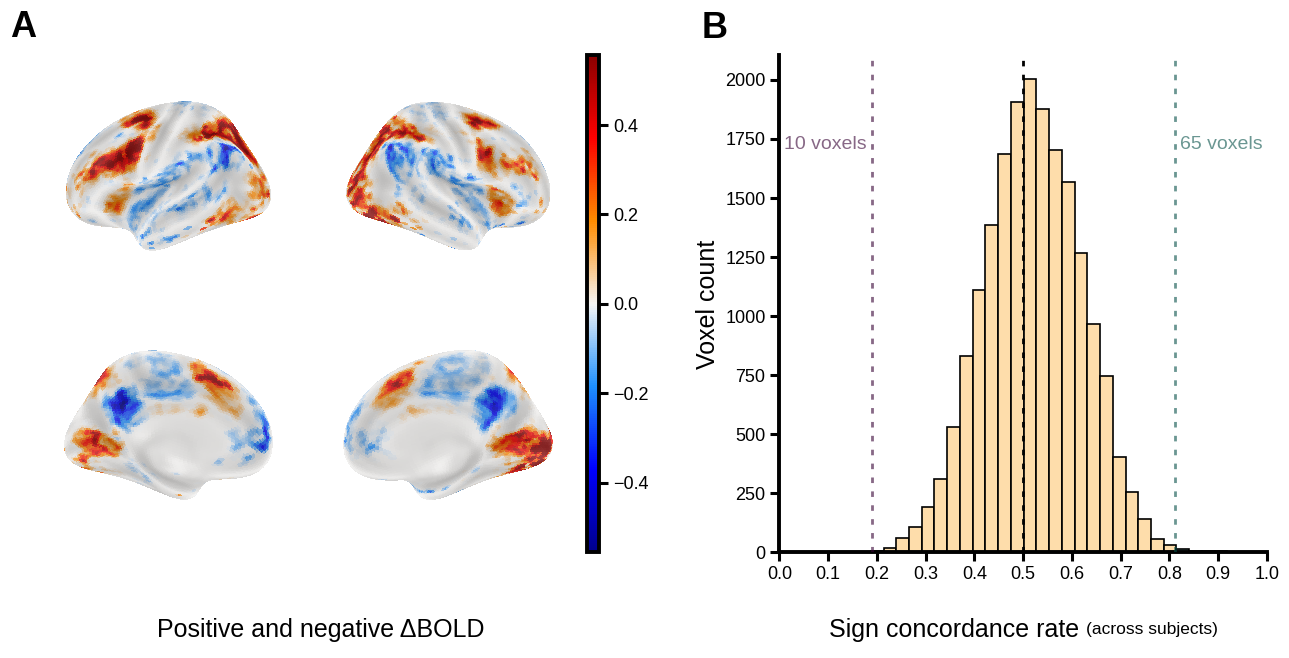

In [ ]:
preferred_fonts = ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"]
available = {f.name for f in fm.fontManager.ttflist}
font = next((f for f in preferred_fonts if f in available), "DejaVu Sans")

plt.rcParams.update({
    "font.family": font,
    "font.size": 12,
    "axes.labelsize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.2,
    "ytick.major.width": 2.2,
    "xtick.major.size": 6.5,
    "ytick.major.size": 6.5,
})

vol_path = results_dir / "calccontrol_Stage1TtestFDR0.05_MeanDeltaBOLD_maskedByBOLDsig.nii.gz"
vol_img = nib.load(vol_path)
fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5") # use fsaverage7 for higher resolution, but code will last for quite some time...
boldsign_csv = results_dir / "calccontrol_Stage1TtestFDR0.05_BOLDsig_voxels.csv"
df_boldsig = pd.read_csv(boldsign_csv)

tex_l = surface.vol_to_surf(vol_img, fsaverage.pial_left,  interpolation="linear")
tex_r = surface.vol_to_surf(vol_img, fsaverage.pial_right, interpolation="linear")

vals = np.hstack([tex_l, tex_r])
vals = vals[np.isfinite(vals)]
m = np.percentile(np.abs(vals), 98)
vmin, vmax = -m, m

BlueRed = LinearSegmentedColormap.from_list(
    "mycmap",
    ["darkblue", "blue", "dodgerblue", "whitesmoke", "darkorange", "red", "darkred"]
)

common = dict(
    cmap=BlueRed,
    vmin=vmin, vmax=vmax,
    threshold=None,
    colorbar=False,
    bg_on_data=True,
)

dotted = (0, (2, 3))

thr_low  = 0.189 # taken from max_pconc_discordant (you get this only if you downloaded data and executed all code)
thr_high = 0.811 # taken from min_pconc_concordant (you get this only if you downloaded data and executed all code)

fig = plt.figure(figsize=(16, 7), facecolor="white")
outer = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.15], wspace=0.34)

gsA = outer[0].subgridspec(2, 3, width_ratios=[1.0, 1.0, 0.045], wspace=0.02, hspace=0.02)

axA1 = fig.add_subplot(gsA[0, 0], projection="3d")
axA2 = fig.add_subplot(gsA[0, 1], projection="3d")
axA3 = fig.add_subplot(gsA[1, 0], projection="3d")
axA4 = fig.add_subplot(gsA[1, 1], projection="3d")
caxA = fig.add_subplot(gsA[:, 2])

plotting.plot_surf_stat_map(fsaverage.infl_left,  tex_l, hemi="left",  view="lateral",
                            bg_map=fsaverage.sulc_left,  axes=axA1, **common)
plotting.plot_surf_stat_map(fsaverage.infl_right, tex_r, hemi="right", view="lateral",
                            bg_map=fsaverage.sulc_right, axes=axA2, **common)
plotting.plot_surf_stat_map(fsaverage.infl_left,  tex_l, hemi="left",  view="medial",
                            bg_map=fsaverage.sulc_left,  axes=axA3, **common)
plotting.plot_surf_stat_map(fsaverage.infl_right, tex_r, hemi="right", view="medial",
                            bg_map=fsaverage.sulc_right, axes=axA4, **common)

sm = ScalarMappable(norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax), cmap=BlueRed)
sm.set_array([])
fig.colorbar(sm, cax=caxA)

axB = fig.add_subplot(outer[1])

x = df_boldsig["p_conc"].dropna().to_numpy()
_, bin_edges, patches = axB.hist(
    x, bins=30, color=nonsign_color, edgecolor="black", linewidth=1.2
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
for center, patch in zip(bin_centers, patches):
    if center <= thr_low:
        patch.set_facecolor(disc_color)
    elif center >= thr_high:
        patch.set_facecolor(conc_color)
    else:
        patch.set_facecolor(nonsign_color)

axB.axvline(thr_low,  color=disc_color,  linewidth=2.0, linestyle=dotted, zorder=5)
axB.axvline(0.5,      color="black", linewidth=2.0, linestyle=dotted, zorder=5)
axB.axvline(thr_high, color=conc_color, linewidth=2.0, linestyle=dotted, zorder=5)

axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)
axB.spines["left"].set_linewidth(2.8)
axB.spines["bottom"].set_linewidth(2.8)

axB.set_xlim(0, 1)
axB.set_xticks(np.round(np.arange(0, 1.01, 0.1), 1))
axB.set_ylabel("Voxel count")
axB.set_xlabel("")

n_discordant = 10 # taken from int(disc_discordant.sum()) --> you get this only if you downloaded data and executed all code, therefore I hardcoded it here
n_concordant = 65 # int(disc_concordant.sum()) --> you get this only if you downloaded data and executed all code, therefore I hardcoded it here
transB = transforms.blended_transform_factory(axB.transData, axB.transAxes)

axB.text(thr_low-0.01,  0.82, f"{n_discordant} voxels", transform=transB,
         ha="right", va="center", fontsize=14, color=disc_color)
axB.text(thr_high+0.01, 0.82, f"{n_concordant} voxels", transform=transB,
         ha="left",  va="center", fontsize=14, color=conc_color)

fig.subplots_adjust(bottom=0.22, top=0.93)

axA1_pos = axA1.get_position()
fig.text(axA1_pos.x0 - 0.02, axA1_pos.y1 + 0.015, "A",
         fontsize=26, fontweight="bold", ha="left", va="bottom")

axB.text(-0.16, 1.02, "B", transform=axB.transAxes,
         fontsize=26, fontweight="bold", ha="left", va="bottom", clip_on=False)

posB = axB.get_position()
pA_left  = axA3.get_position().x0
pA_right = caxA.get_position().x1
xA_center = 0.5 * (pA_left + pA_right)
xB_center = 0.5 * (posB.x0 + posB.x1)

y_line = posB.y0
y_text = posB.y0 - 0.11

fig.text(xA_center, y_text, "Positive and negative ΔBOLD",
         ha="center", va="center", fontsize=18, color="black")

main = TextArea("Sign concordance rate ", textprops=dict(size=18, weight="regular"))
bracket = TextArea("(across subjects)", textprops=dict(size=12.5, weight="light"))
packed = HPacker(children=[main, bracket], align="center", pad=0, sep=0)

xlabel_box = AnchoredOffsetbox(
    loc="center",
    child=packed,
    frameon=False,
    bbox_to_anchor=(xB_center, y_text),
    bbox_transform=fig.transFigure,
    borderpad=0.0
)
fig.add_artist(xlabel_box)

fig.savefig(os.path.join(fig_dir, "Figure2.png"), dpi=400, bbox_inches="tight")
fig.savefig(os.path.join(fig_dir, "Figure2.svg"), bbox_inches="tight")

plt.show()


## 9. **Group-level ΔCMRO₂ Classification**  

In [24]:
# --------------------------------------------------
# Stage 1: BOLD PSC mean != 0 (t-test) + BH-FDR(0.05) gate
# Stage 2: dCMRO2 mean != 0 (t-test) + BH-FDR(0.05) within gate
# --------------------------------------------------

if not download:
    print("download = False → skipping BOLD/CMRO2 t-test analysis (using results shipped with repo).")

else:

    # ============================================================
    # Config
    # ============================================================

    alpha_bold = 0.05
    alpha_cmro2 = 0.05

    # -------------------------
    # Path helpers
    # -------------------------
    def bold_percchange_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "func",
            f"{sub}_task-{con}_space-MNI152_res-2_desc-percchange_bold.nii.gz"
        )


    def cmro2_baseline_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{baseline}_space-MNI152_desc-orig_cmro2.nii.gz"
        )


    def cmro2_task_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{task}_base-{baseline}_space-MNI_desc-semi-quant-corrected_cmro2.nii.gz"
        )

    # -------------------------
    # Mask + helpers
    # -------------------------
    if not os.path.exists(whole_brain_mask):
        raise FileNotFoundError(f"Mask not found: {whole_brain_mask}")

    mask_img = load_img(whole_brain_mask)

    def sanitize_then_resample(path: str, ref_img, interpolation="continuous", fill=0.0):
        img = load_img(path)
        data = img.get_fdata(dtype=np.float32)
        data[~np.isfinite(data)] = fill
        return resample_to_img(new_img_like(img, data), ref_img, interpolation=interpolation)

    masker = NiftiMasker(mask_img=mask_img).fit()

    # -------------------------
    # Load subject vectors
    # -------------------------
    bold_list, dcmr_list, kept_sids, skipped = [], [], [], []

    for ID in sids:
        sub = f"sub-p{ID:03d}"
        f_bold = bold_percchange_path(sub)
        f_cmr0 = cmro2_baseline_path(sub)
        f_cmrt = cmro2_task_path(sub)

        missing = [f for f in (f_bold, f_cmr0, f_cmrt) if not os.path.exists(f)]
        if missing:
            skipped.append((sub, missing))
            continue

        try:
            bold_img = sanitize_then_resample(f_bold, mask_img)
            cmr0_img = sanitize_then_resample(f_cmr0, mask_img)
            cmrt_img = sanitize_then_resample(f_cmrt, mask_img)

            bold_v = masker.transform(bold_img).ravel().astype(np.float64)
            cmr0_v = masker.transform(cmr0_img).ravel().astype(np.float64)
            cmrt_v = masker.transform(cmrt_img).ravel().astype(np.float64)

            cmr0_v[~np.isfinite(cmr0_v)] = np.nan
            cmr0_v[cmr0_v <= 0] = np.nan
            dcmr_v = (cmrt_v - cmr0_v) / cmr0_v * 100.0
            dcmr_v[~np.isfinite(dcmr_v)] = np.nan

            bold_list.append(bold_v)
            dcmr_list.append(dcmr_v)
            kept_sids.append(ID)

        except Exception as e:
            skipped.append((sub, [f"{type(e).__name__}: {e}"]))

    bold_arr = np.asarray(bold_list)
    dcmr_arr = np.asarray(dcmr_list)

    print("\n====================")
    print(f"Subjects requested: {len(sids)}")
    print(f"Subjects kept:      {len(kept_sids)}")
    print(f"Subjects skipped:   {len(skipped)}")
    print("====================\n")

    if len(kept_sids) < 5:
        raise RuntimeError("Too few subjects kept.")

    # -------------------------
    # Descriptive means
    # -------------------------
    bold_mean = np.nanmean(bold_arr, axis=0)
    dcmr_mean = np.nanmean(dcmr_arr, axis=0)

    # ============================================================
    # Stage 1: BOLD mean != 0 (t-test + FDR)
    # ============================================================
    tB, pB = ttest_1samp(bold_arr, popmean=0.0, axis=0, nan_policy="omit")
    pB = np.asarray(pB, dtype=np.float64)
    tB = np.asarray(tB, dtype=np.float64)
    pB[~np.isfinite(pB)] = 1.0
    tB[~np.isfinite(tB)] = 0.0

    bold_sig, qB = fdrcorrection(pB, alpha=alpha_bold)

    bold_pos = bold_sig & (bold_mean > 0)
    bold_neg = bold_sig & (bold_mean < 0)

    print("Stage 1 (BOLD PSC mean != 0)")
    print(f"  voxels total:             {bold_sig.size}")
    print(f"  significant (FDR<{alpha_bold}): {int(bold_sig.sum())}")
    print(f"    BOLD mean > 0:           {int(bold_pos.sum())}")
    print(f"    BOLD mean < 0:           {int(bold_neg.sum())}")

    # ============================================================
    # Stage 2: dCMRO2 mean != 0 within BOLD gate
    # ============================================================
    tM, pM = ttest_1samp(dcmr_arr, popmean=0.0, axis=0, nan_policy="omit")
    pM = np.asarray(pM, dtype=np.float64)
    tM = np.asarray(tM, dtype=np.float64)
    pM[~np.isfinite(pM)] = 1.0
    tM[~np.isfinite(tM)] = 0.0

    cmro2_sig = np.zeros_like(bold_sig, dtype=bool)
    qM = np.ones_like(pM, dtype=np.float64)

    gate = bold_sig.copy()

    if gate.any():
        cmro2_sig_gate, qM_gate = fdrcorrection(pM[gate], alpha=alpha_cmro2)
        cmro2_sig[gate] = cmro2_sig_gate
        qM[gate] = qM_gate

    print("\nStage 2 (ΔCMRO2 mean != 0) within BOLD-significant voxels")
    print(f"  voxels tested (gate):          {int(gate.sum())}")
    print(f"  significant CMRO2 (FDR<{alpha_cmro2} within gate): {int(cmro2_sig.sum())}")

    # ============================================================
    # Sign coherence
    # ============================================================
    tested_and_sig = gate & cmro2_sig

    same_sign = tested_and_sig & (np.sign(bold_mean) == np.sign(dcmr_mean)) & (bold_mean != 0) & (dcmr_mean != 0)
    mismatch  = tested_and_sig & (np.sign(bold_mean) != np.sign(dcmr_mean)) & (bold_mean != 0) & (dcmr_mean != 0)

    def report_block(name, mask):
        n_gate = int(mask.sum())
        n_cmro2 = int((cmro2_sig & mask).sum())
        n_same = int((same_sign & mask).sum())
        n_mis  = int((mismatch & mask).sum())
        print(f"\n{name}")
        print(f"  voxels in BOLD gate:      {n_gate}")
        print(f"  CMRO2 mean!=0 significant: {n_cmro2} ({(100*n_cmro2/n_gate if n_gate else 0):.2f}%)")
        if n_cmro2 > 0:
            print(f"    sign coherent (mean signs match):   {n_same} ({100*n_same/n_cmro2:.2f}%)")
            print(f"    sign mismatch (mean signs differ): {n_mis} ({100*n_mis/n_cmro2:.2f}%)")

    print("\n===== Report inside BOLD-significant voxels =====")
    report_block("BOLD mean > 0", bold_pos)
    report_block("BOLD mean < 0", bold_neg)

    print("\nOverall (within gate & CMRO2 significant):")
    print(f"  total CMRO2-significant voxels: {int(tested_and_sig.sum())}")
    print(f"  coherent: {int(same_sign.sum())}")
    print(f"  mismatch: {int(mismatch.sum())}")

    # ============================================================
    # Save outputs
    # ============================================================
    tag = f"{task}{baseline}_BOLDttestFDR{alpha_bold:g}_CMRO2ttestFDR{alpha_cmro2:g}_withinGate"

    out_boldgate = os.path.join(results_dir, f"{tag}_BOLDsig_mask.nii.gz")
    out_cmro2sig = os.path.join(results_dir, f"{tag}_CMRO2sig_withinBOLDgate_mask.nii.gz")
    out_coh      = os.path.join(results_dir, f"{tag}_SignCoherent_mask.nii.gz")
    out_mis      = os.path.join(results_dir, f"{tag}_SignMismatch_mask.nii.gz")

    nib.save(masker.inverse_transform(bold_sig.astype(np.float32)), out_boldgate)
    nib.save(masker.inverse_transform(cmro2_sig.astype(np.float32)), out_cmro2sig)
    nib.save(masker.inverse_transform(same_sign.astype(np.float32)), out_coh)
    nib.save(masker.inverse_transform(mismatch.astype(np.float32)), out_mis)

    print("\nSaved:")
    for p in [out_boldgate, out_cmro2sig, out_coh, out_mis]:
        print(" ", p)

download = False → skipping BOLD/CMRO2 t-test analysis (using results shipped with repo).


## 10. **Get CBF data for Figure 3A and save concordancy.csv**  

In [27]:
# --------------------------------------------------
# Compute ΔCBF median + build voxelwise table + save concordancy.csv
# (only if dataset was downloaded)
# --------------------------------------------------

if not download:
    print("download = False → skipping ΔCBF/concordancy computation (using results shipped with repo).")

else:

    # ---------- prerequisites ----------
    required = [
        "derivatives_dir", "baseline", "task", "kept_sids",
        "mask_img", "masker", "sanitize_then_resample",
        "bold_mean", "dcmr_mean", "bold_sig", "cmro2_sig",
        "results_dir"
    ]
    missing = [v for v in required if v not in globals()]
    if missing:
        raise NameError("Missing required variables from previous cells: " + ", ".join(missing))

    # Use your script's naming for the BOLD gate
    considered = bold_sig  # BOLD-significant voxels (FDR gate)

    # ---------- CBF path helpers ----------
    def cbf_baseline_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{baseline}_space-MNI152_cbf.nii.gz"
        )


    def cbf_task_path(sub: str) -> str:
        return os.path.join(
            derivatives_dir, sub, "qmri",
            f"{sub}_task-{task}_space-MNI152_cbf.nii.gz"
        )

    # ---------- Load CBF per kept subject and compute ΔCBF (%change), calibrated by /0.75 ----------
    dcbf_list = []
    cbf_skipped = []

    for ID in kept_sids:
        sub = f"sub-p{ID:03d}"
        f_cbf0 = cbf_baseline_path(sub)
        f_cbft = cbf_task_path(sub)

        missing_files = [p for p in (f_cbf0, f_cbft) if not os.path.exists(p)]
        if missing_files:
            cbf_skipped.append((sub, missing_files))
            continue

        try:
            cbf0_img = sanitize_then_resample(f_cbf0, mask_img)
            cbft_img = sanitize_then_resample(f_cbft, mask_img)

            # vectorize on SAME masker grid/order as BOLD/CMRO2
            cbf0_v = masker.transform(cbf0_img).ravel().astype(np.float64) / 0.75
            cbft_v = masker.transform(cbft_img).ravel().astype(np.float64) / 0.75

            # ΔCBF percent change vs baseline
            cbf0_v[~np.isfinite(cbf0_v)] = np.nan
            cbf0_v[cbf0_v == 0] = np.nan
            dcbf_v = (cbft_v - cbf0_v) / cbf0_v * 100.0
            dcbf_v[~np.isfinite(dcbf_v)] = np.nan

            dcbf_list.append(dcbf_v)

        except Exception as e:
            cbf_skipped.append((sub, [f"{type(e).__name__}: {e}"]))

    # Must match number of kept subjects used for bold/cMRO2
    if len(dcbf_list) != len(kept_sids):
        print("CBF not available for all kept subjects.")
        print(f"kept_sids: {len(kept_sids)}  |  cbf loaded: {len(dcbf_list)}  |  cbf skipped: {len(cbf_skipped)}")
        for sub, why in cbf_skipped[:10]:
            print("  [CBF SKIP]", sub, "->", (why[0] if why else "unknown"))
        raise RuntimeError(
            "CBF loading did not match kept_sids. "
            "To keep voxelwise group estimates aligned across modalities, "
            "either (1) ensure CBF exists for all kept_sids, or (2) recompute kept_sids "
            "as the intersection of subjects with BOLD+CMRO2+CBF."
        )

    dcbf_arr = np.asarray(dcbf_list)           # (Nsub, Nvox)
    cbf_mean = np.nanmean(dcbf_arr, axis=0)    # (Nvox,)

    # ---------- Hard voxel-alignment checks ----------
    nvox = int(bold_mean.shape[0])
    assert dcmr_mean.shape[0] == nvox, f"Voxel mismatch: dcmr_mean {dcmr_mean.shape[0]} vs bold_mean {nvox}"
    assert cbf_mean.shape[0] == nvox, f"Voxel mismatch: cbf_mean {cbf_mean.shape[0]} vs bold_mean {nvox}"
    assert considered.shape[0] == nvox, f"Voxel mismatch: considered {considered.shape[0]} vs bold_mean {nvox}"
    assert cmro2_sig.shape[0] == nvox, f"Voxel mismatch: cmro2_sig {cmro2_sig.shape[0]} vs bold_mean {nvox}"

    print(f"✅ CBF loaded & aligned: dcbf_arr shape = {dcbf_arr.shape}, cbf_mean shape = {cbf_mean.shape}")

    # ---------- Build voxelwise table to save ----------
    df_fig2 = pd.DataFrame({
        "voxel": np.arange(nvox, dtype=np.int32),
        "bold_mean": bold_mean.astype(np.float32),
        "dcmro2_mean": dcmr_mean.astype(np.float32),
        "dcbf_mean": cbf_mean.astype(np.float32),
        "considered": considered.astype(np.int8),  # BOLD gate (FDR significant)
        "cmro2_sig": cmro2_sig.astype(np.int8),    # CMRO2 significant within gate
    })

    # handy QA column
    df_fig2["finite_all"] = (
        np.isfinite(df_fig2["bold_mean"]) &
        np.isfinite(df_fig2["dcmro2_mean"]) &
        np.isfinite(df_fig2["dcbf_mean"])
    ).astype(np.int8)

    out_csv = os.path.join(results_dir, "concordancy.csv")
    df_fig2.to_csv(out_csv, index=False)

    print(f"✅ Wrote: {out_csv}")
    print(df_fig2.head())

download = False → skipping ΔCBF/concordancy computation (using results shipped with repo).


## 11. **Figure 3**  

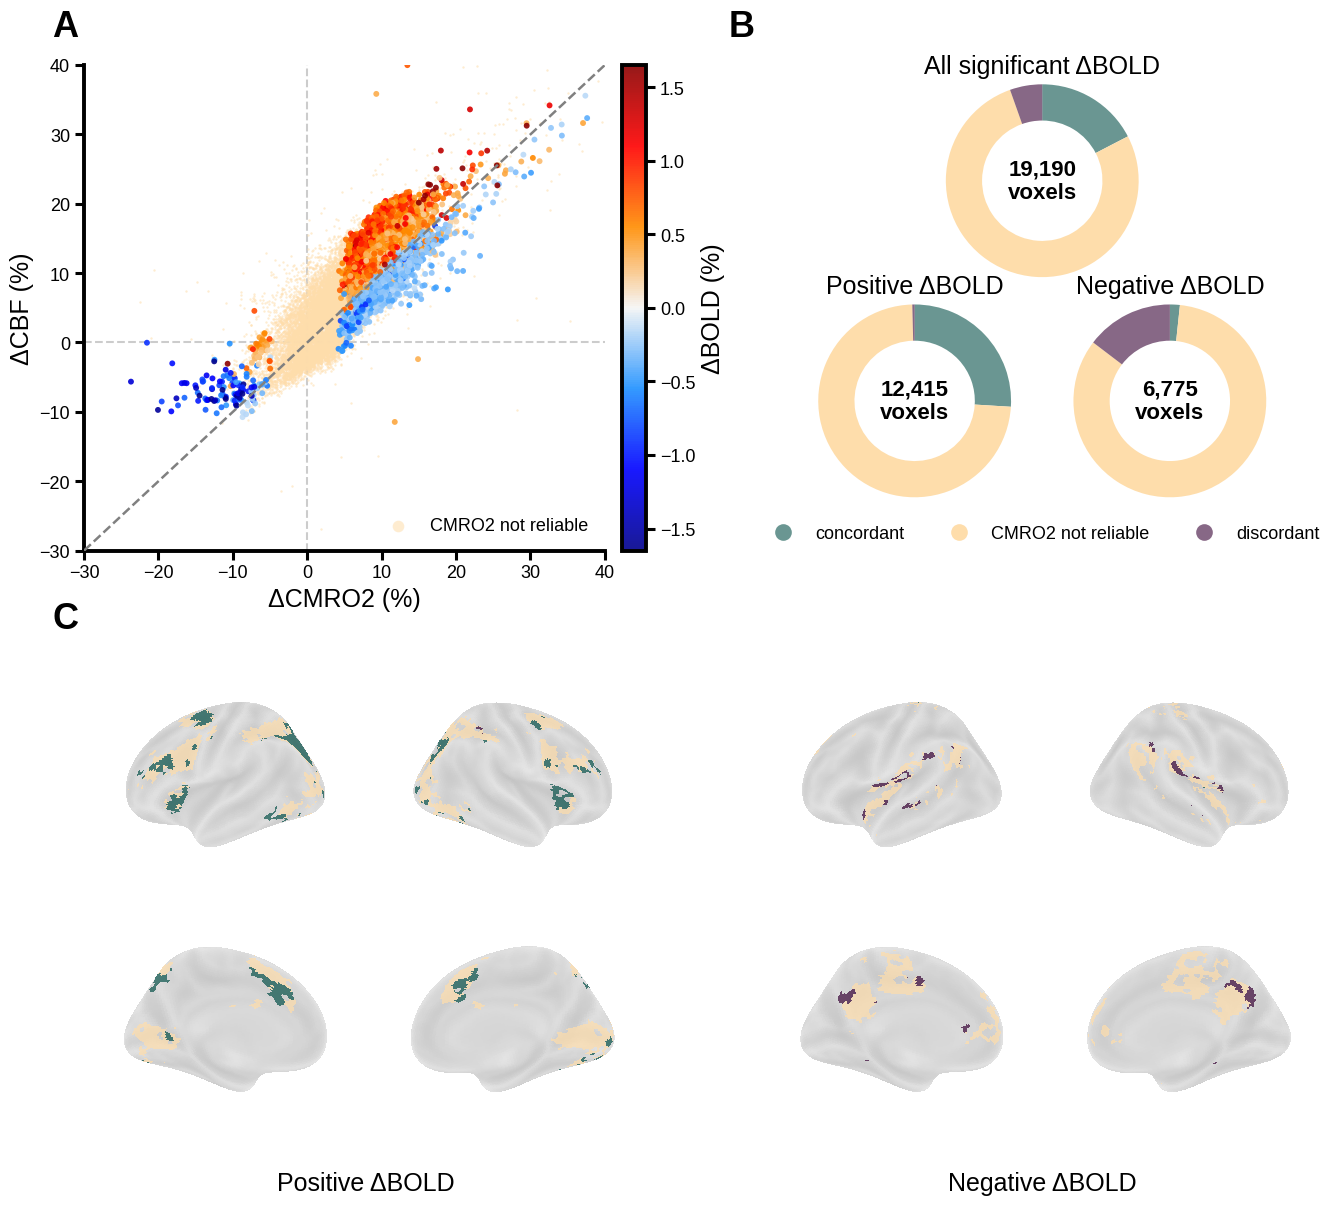

Saved:
  /home/ole/projects/BOLD_metabolism_reanalysis/figures/Figure3.png
  /home/ole/projects/BOLD_metabolism_reanalysis/figures/Figure3.svg


In [ ]:
# =========================
# Figure 3: 2x2 panels
# A: Scatter (ΔCMRO2 vs ΔCBF) colored by ΔBOLD
# B: 3 donuts + legend
# C: Surface categorical map 
#
# Saves: figures/Figure3.png and Figure3.svg
# =========================

# -------------------------
# Style
# -------------------------
DONUT_TITLE_SIZE = plt.rcParams["axes.labelsize"]
PANEL_LABEL_SIZE = 26

# -------------------------
# Load concordancy.csv
# -------------------------
df_conc = pd.read_csv(os.path.join(results_dir, "concordancy.csv"))

bold_mean = df_conc["bold_mean"].to_numpy(dtype=np.float64)
cmro2_mean = df_conc["dcmro2_mean"].to_numpy(dtype=np.float64)
cbf_mean = df_conc["dcbf_mean"].to_numpy(dtype=np.float64)

considered = df_conc["considered"].to_numpy(dtype=bool)
cmro2_sig = df_conc["cmro2_sig"].to_numpy(dtype=bool)

nvox = bold_mean.size

# -------------------------
# Colors
# -------------------------
colors_common = [conc_color, nonsign_color, disc_color]

BlueRed = LinearSegmentedColormap.from_list(
    "mycmap",
    ["darkblue", "blue", "dodgerblue", "whitesmoke", "darkorange", "red", "darkred"]
)

# =========================
# Panel A prep
# =========================
plot_mask = considered.copy()
plot_mask &= np.isfinite(cmro2_mean) & np.isfinite(cbf_mean) & np.isfinite(bold_mean)

reliable = plot_mask & cmro2_sig
nonrel = plot_mask & (~cmro2_sig)

cvals = bold_mean[reliable]
vabs = np.nanpercentile(np.abs(cvals), 98) if cvals.size else 1.0
if not np.isfinite(vabs) or vabs == 0:
    vabs = np.nanmax(np.abs(cvals)) if cvals.size else 1.0
    if not np.isfinite(vabs) or vabs == 0:
        vabs = 1.0
norm = Normalize(vmin=-vabs, vmax=vabs)

# =========================
# Concordance classes
# =========================
bold_dir = np.sign(bold_mean)
cmro2_dir = np.sign(cmro2_mean)

valid_signs = (bold_dir != 0) & (cmro2_dir != 0)
same_sign = valid_signs & (bold_dir == cmro2_dir)
mismatch = valid_signs & (bold_dir != cmro2_dir)

conc_considered = considered & cmro2_sig & same_sign
disc_considered = considered & cmro2_sig & mismatch
nsig_considered = considered & (~cmro2_sig)

pos_bold = considered & (bold_mean > 0)
neg_bold = considered & (bold_mean < 0)

def counts_for(conc_mask, nsig_mask, disc_mask, subset_mask=None):
    if subset_mask is None:
        return np.array([
            int(conc_mask.sum()),
            int(nsig_mask.sum()),
            int(disc_mask.sum())
        ], dtype=int)
    return np.array([
        int((conc_mask & subset_mask).sum()),
        int((nsig_mask & subset_mask).sum()),
        int((disc_mask & subset_mask).sum())
    ], dtype=int)

cons_counts = counts_for(conc_considered, nsig_considered, disc_considered, None)
pos_counts = counts_for(conc_considered, nsig_considered, disc_considered, pos_bold)
neg_counts = counts_for(conc_considered, nsig_considered, disc_considered, neg_bold)

def draw_donut(ax, counts, colors, title, startangle=90, title_pad=6):
    total = int(counts.sum())
    if total == 0:
        ax.text(0.5, 0.5, "0 voxels", ha="center", va="center", fontsize=14)
        ax.set_title(title, fontweight="normal", fontsize=DONUT_TITLE_SIZE, pad=title_pad)
        ax.axis("off")
        return

    ax.pie(
        counts,
        colors=colors,
        startangle=startangle,
        counterclock=False,
        radius=1.65,
        wedgeprops=dict(width=0.62),
        labels=None,
        autopct=None
    )

    ax.text(
        0, 0, f"{total:,}\nvoxels",
        ha="center", va="center",
        fontsize=16, fontweight="bold"
    )

    ax.set_title(title, fontweight="normal", fontsize=DONUT_TITLE_SIZE, pad=title_pad)
    ax.set_aspect("equal")
    ax.set_xlim(-1.70, 1.70)
    ax.set_ylim(-1.70, 1.70)
    ax.margins(0)

# =========================
# Surface maps setup
# =========================
mask_img = load_img(whole_brain_mask)
masker = NiftiMasker(mask_img=mask_img).fit()

def build_label_img(subset_mask_bool):
    # 0 background, 1 conc, 2 nsig, 3 disc
    lab = np.zeros(nvox, dtype=np.int16)
    sub = subset_mask_bool.copy()
    lab[sub & conc_considered] = 1
    lab[sub & nsig_considered] = 2
    lab[sub & disc_considered] = 3
    return masker.inverse_transform(lab.astype(np.float32))

cmap_cat = ListedColormap([
    (0, 0, 0, 0),
    mpl.colors.to_rgba(conc_color),
    mpl.colors.to_rgba(nonsign_color),
    mpl.colors.to_rgba(disc_color),
])

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5") # change to fsaverage7 if you want higher resolution (but longer running time)

def make_light_sulc_bg(sulc_path, base=0.14, contrast=0.12, gamma=0.75):
    sulc = surface.load_surf_data(sulc_path).astype(np.float32)
    sulc[~np.isfinite(sulc)] = 0.0
    mn, mx = float(sulc.min()), float(sulc.max())

    if mx - mn < 1e-12:
        z = np.zeros_like(sulc)
    else:
        z = (sulc - mn) / (mx - mn)

    z = np.power(z, gamma)
    bg = base + contrast * (z - 0.5)
    return np.clip(bg, 0.0, 1.0)

bg_l = make_light_sulc_bg(fsaverage.sulc_left, base=0.16, contrast=0.15, gamma=0.8)
bg_r = make_light_sulc_bg(fsaverage.sulc_right, base=0.16, contrast=0.15, gamma=0.8)

def _project_labels_wta_linear(label_img, hemi, conf_thr=0.12):
    lab_data = np.asarray(label_img.get_fdata(), dtype=np.int16)

    bin_imgs = []
    for k in (1, 2, 3):
        bin_k = (lab_data == k).astype(np.float32)
        bin_imgs.append(nib.Nifti1Image(bin_k, affine=label_img.affine))

    mesh = fsaverage.pial_left if hemi == "left" else fsaverage.pial_right

    proj = []
    for imgk in bin_imgs:
        proj.append(surface.vol_to_surf(imgk, mesh, interpolation="linear"))
    proj = np.vstack(proj)

    win = np.argmax(proj, axis=0) + 1
    conf = np.max(proj, axis=0)

    tex = win.astype(np.float32)
    tex[conf < conf_thr] = np.nan
    return tex

def plot_category_surface(fig, bbox, label_img, title_text, title_below=True):
    x0, y0, w, h = bbox

    gap_x = 0.02 * w
    gap_y = 0.015 * h
    col_w = (w - gap_x) / 2.0
    row_h = (h - gap_y) / 2.0

    axL_lat = fig.add_axes([x0,                 y0 + row_h + gap_y, col_w, row_h], projection="3d")
    axR_lat = fig.add_axes([x0 + col_w + gap_x, y0 + row_h + gap_y, col_w, row_h], projection="3d")
    axL_med = fig.add_axes([x0,                 y0,                 col_w, row_h], projection="3d")
    axR_med = fig.add_axes([x0 + col_w + gap_x, y0,                 col_w, row_h], projection="3d")

    tex_l = _project_labels_wta_linear(label_img, hemi="left", conf_thr=0.12)
    tex_r = _project_labels_wta_linear(label_img, hemi="right", conf_thr=0.12)

    common_roi = dict(
        cmap=cmap_cat,
        vmin=0,
        vmax=3,
        colorbar=False,
        bg_on_data=True,
        threshold=None,
    )

    plotting.plot_surf_roi(
        fsaverage.infl_left, tex_l, hemi="left", view="lateral",
        bg_map=bg_l, axes=axL_lat, **common_roi
    )
    plotting.plot_surf_roi(
        fsaverage.infl_right, tex_r, hemi="right", view="lateral",
        bg_map=bg_r, axes=axR_lat, **common_roi
    )
    plotting.plot_surf_roi(
        fsaverage.infl_left, tex_l, hemi="left", view="medial",
        bg_map=bg_l, axes=axL_med, **common_roi
    )
    plotting.plot_surf_roi(
        fsaverage.infl_right, tex_r, hemi="right", view="medial",
        bg_map=bg_r, axes=axR_med, **common_roi
    )

    for ax in (axL_lat, axR_lat, axL_med, axR_med):
        ax.set_axis_off()

    if title_below:
        fig.text(
            x0 + w / 2.0, y0 - 0.02, title_text,
            ha="center", va="top",
            fontsize=plt.rcParams["axes.labelsize"],
            fontweight="normal"
        )
    else:
        fig.text(
            x0 + w / 2.0, y0 + h + 0.01, title_text,
            ha="center", va="bottom",
            fontsize=plt.rcParams["axes.labelsize"],
            fontweight="normal"
        )

# =========================
# Build Figure2 (2x2)
# =========================
fig = plt.figure(figsize=(16, 14), facecolor="white")

outer = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[1.0, 1.0],
    height_ratios=[1.0, 1.0],
    wspace=0.20,
    hspace=0.22
)

# -------------------------
# Panel A
# -------------------------
axA = fig.add_subplot(outer[0, 0])

axA.scatter(
    cmro2_mean[nonrel],
    cbf_mean[nonrel],
    s=3,
    c=nonsign_color,
    alpha=0.55,
    linewidths=0,
    label="CMRO2 not reliable",
    zorder=2
)

sc = axA.scatter(
    cmro2_mean[reliable],
    cbf_mean[reliable],
    s=18,
    c=bold_mean[reliable],
    cmap=BlueRed,
    norm=norm,
    alpha=0.90,
    linewidths=0,
    zorder=3
)

cbar = fig.colorbar(sc, ax=axA, fraction=0.046, pad=0.03)
cbar.set_label("ΔBOLD (%)", fontsize=plt.rcParams["axes.labelsize"])
cbar.ax.tick_params(
    labelsize=plt.rcParams["xtick.labelsize"],
    width=plt.rcParams["xtick.major.width"],
    length=plt.rcParams["xtick.major.size"]
)

axA.axhline(0, color="grey", alpha=0.4, linestyle="dashed", zorder=1)
axA.axvline(0, color="grey", alpha=0.4, linestyle="dashed", zorder=1)

axA.set_xlabel("ΔCMRO2 (%)")
axA.set_ylabel("ΔCBF (%)")
axA.set_xlim(-30, 40)
axA.set_ylim(-30, 40)

axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)
axA.spines["left"].set_linewidth(plt.rcParams["axes.linewidth"])
axA.spines["bottom"].set_linewidth(plt.rcParams["axes.linewidth"])

axA.tick_params(
    axis="both",
    which="major",
    width=plt.rcParams["xtick.major.width"],
    length=plt.rcParams["xtick.major.size"]
)

xmin, xmax = axA.get_xlim()
ymin, ymax = axA.get_ylim()
lo = max(xmin, ymin)
hi = min(xmax, ymax)
axA.plot([lo, hi], [lo, hi], linestyle="--", color="0.5", linewidth=1.8, zorder=50)

legA = axA.legend(loc="lower right", frameon=False, fontsize=13, scatterpoints=1)
for text, handle in zip(legA.get_texts(), legA.legend_handles):
    if text.get_text() == "CMRO2 not reliable" and hasattr(handle, "set_sizes"):
        handle.set_sizes([70])

axA_pos = axA.get_position()
fig.text(
    axA_pos.x0 - 0.02, axA_pos.y1 + 0.015, "A",
    fontsize=PANEL_LABEL_SIZE, fontweight="bold", ha="left", va="bottom"
)

# -------------------------
# Panel B
# -------------------------
axB_container = fig.add_subplot(outer[0, 1])
axB_container.axis("off")

bboxB = axB_container.get_position(fig)
x0, y0, w, h = bboxB.x0, bboxB.y0, bboxB.width, bboxB.height

leg_h_frac = 0.07
leg_h = leg_h_frac * h
donut_y0 = y0 + leg_h
donut_h = h - leg_h

pad_x = 0.02 * w
pad_y = 0.02 * donut_h
row_gap = 0.015 * donut_h

usable_w = w - 2 * pad_x
usable_h = donut_h - 2 * pad_y - row_gap
row_h = usable_h / 2.0

bottom_gap = 0.05 * w
max_size_by_width = (usable_w - bottom_gap) / 2.0
max_size_by_height = row_h * 0.98
donut_size = 0.95 * min(max_size_by_height, max_size_by_width)

cx_mid = x0 + w / 2.0
cy_bottom = donut_y0 + pad_y + row_h / 2.0
cy_top = donut_y0 + pad_y + row_h + row_gap + row_h / 2.0

cx_left = cx_mid - (donut_size / 2.0 + bottom_gap / 2.0)
cx_right = cx_mid + (donut_size / 2.0 + bottom_gap / 2.0)

ax_cons = fig.add_axes([cx_mid - donut_size / 2.0, cy_top - donut_size / 2.0, donut_size, donut_size])
ax_pos = fig.add_axes([cx_left - donut_size / 2.0, cy_bottom - donut_size / 2.0, donut_size, donut_size])
ax_neg = fig.add_axes([cx_right - donut_size / 2.0, cy_bottom - donut_size / 2.0, donut_size, donut_size])

draw_donut(ax_cons, cons_counts, colors_common, "All significant ΔBOLD", title_pad=6)
draw_donut(ax_pos, pos_counts, colors_common, "Positive ΔBOLD", title_pad=6)
draw_donut(ax_neg, neg_counts, colors_common, "Negative ΔBOLD", title_pad=6)

fig.text(
    x0 - 0.02, y0 + h + 0.015, "B",
    fontsize=PANEL_LABEL_SIZE, fontweight="bold", ha="left", va="bottom"
)

ax_leg = fig.add_axes([x0, y0, w, leg_h])
ax_leg.axis("off")

h_conc = plt.Line2D([0], [0], marker="o", linestyle="None",
                    markerfacecolor=conc_color, markeredgecolor="none", markersize=12)
h_nsig = plt.Line2D([0], [0], marker="o", linestyle="None",
                    markerfacecolor=nonsign_color, markeredgecolor="none", markersize=12)
h_disc = plt.Line2D([0], [0], marker="o", linestyle="None",
                    markerfacecolor=disc_color, markeredgecolor="none", markersize=12)

ax_leg.legend(
    handles=[h_conc, h_nsig, h_disc],
    labels=["concordant", "CMRO2 not reliable", "discordant"],
    loc="center",
    ncol=3,
    frameon=False,
    prop={"family": font, "size": 13}
)

# -------------------------
# Panel C
# -------------------------
axC_container = fig.add_subplot(outer[1, 0])
axC_container.axis("off")
bboxC = axC_container.get_position(fig)

img_pos = build_label_img(pos_bold)
plot_category_surface(
    fig,
    (bboxC.x0, bboxC.y0, bboxC.width, bboxC.height),
    img_pos,
    "Positive ΔBOLD",
    title_below=True
)

fig.text(
    bboxC.x0 - 0.02, bboxC.y1 + 0.015, "C",
    fontsize=PANEL_LABEL_SIZE, fontweight="bold", ha="left", va="bottom"
)

# -------------------------
# Panel D
# -------------------------
axD_container = fig.add_subplot(outer[1, 1])
axD_container.axis("off")
bboxD = axD_container.get_position(fig)

img_neg = build_label_img(neg_bold)
plot_category_surface(
    fig,
    (bboxD.x0, bboxD.y0, bboxD.width, bboxD.height),
    img_neg,
    "Negative ΔBOLD",
    title_below=True
)

# -------------------------
# Save
# -------------------------
out_png = os.path.join(fig_dir, "Figure3.png")
out_svg = os.path.join(fig_dir, "Figure3.svg")

fig.savefig(out_png, dpi=400, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(" ", out_png)
print(" ", out_svg)